In [1]:
import torch
from train import train
from lofi_model import LofiModel
from dataset import MidiDataset
import pretty_midi
import numpy as np
from config import *
print(torch.__version__)
print(torch.version.cuda)

c:\Users\Hyperbook\Desktop\STUDIA\SEM III\PROJEKT ZESPOLOWY\venv\Lib\site-packages\pretty_midi\instrument.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


2.7.1+cu118
11.8


## Generation

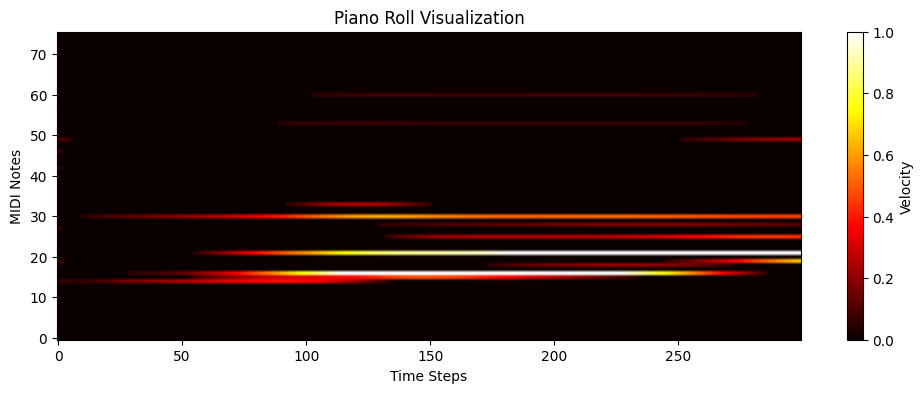

Successfully saved MIDI file to ./generated/lofi_generated.mid


In [2]:
model = LofiModel()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
model.load_state_dict(torch.load("./saved_models/progress/lofi-model_epoch200.pth"))
model.to(device)
generated = model.generate(max_len=MAX_SEQ_LEN, threshold=0.05, visualize=True, save_path="./generated/lofi_generated.mid")

In [3]:
generated

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0547, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]])

In [4]:
import torch
import os
import numpy as np
import pretty_midi
from lofi_model import LofiModel # Make sure your model class is importable
from config import * # Import all your configuration variables

# In your generate.py script

def pianoroll_to_instrument(piano_roll, fs, program=0):
    """
    Converts a piano roll numpy array into a PrettyMIDI Instrument object.
    (This version is robust against silent piano rolls).
    """
    instrument = pretty_midi.Instrument(program=program, is_drum=True, name="Generated Drums")
    
    notes, frames = piano_roll.shape
    piano_roll = np.pad(piano_roll, [(0, 0), (0, 1)], 'constant')
    velocity_threshold = 10 

    for pitch in range(notes):
        # Find the frames where this pitch is active
        frames_where_pitch_is_on = np.where(piano_roll[pitch] > velocity_threshold)[0]
        
        # --- THIS IS THE FIX ---
        # If there are no active frames for this pitch, skip to the next pitch.
        if len(frames_where_pitch_is_on) == 0:
            continue
        # --- END OF FIX ---
        
        frame_diffs = np.diff(frames_where_pitch_is_on)
        
        # Find the start of each note event
        start_frames = np.where(frame_diffs > 1)[0]
        start_frames = np.append(0, start_frames + 1)
        start_frames = frames_where_pitch_is_on[start_frames]
        
        # Find the end of each note event
        end_frames = np.where(frame_diffs > 1)[0]
        end_frames = frames_where_pitch_is_on[end_frames]
        end_frames = np.append(end_frames, frames_where_pitch_is_on[-1])

        for i in range(len(start_frames)):
            start_time = start_frames[i] / fs
            end_time = (end_frames[i] + 1) / fs
            
            velocity = int(piano_roll[pitch, start_frames[i]])

            note = pretty_midi.Note(
                velocity=velocity,
                pitch=pitch,
                start=start_time,
                end=end_time
            )
            instrument.notes.append(note)

    return instrument


def pianoroll_tensor_to_midi(pianoroll_tensor, output_path):
    """
    Converts a piano roll tensor back into a MIDI file.
    (This function now uses our new helper).
    """
    if pianoroll_tensor.is_cuda:
        pianoroll_tensor = pianoroll_tensor.cpu()
        
    if pianoroll_tensor.dim() == 4:
        pianoroll_tensor = pianoroll_tensor.squeeze(0)
    
    pianoroll_tensor = pianoroll_tensor.squeeze(0)

    pianoroll_velocities = pianoroll_tensor * 127.0
    pianoroll_np = pianoroll_velocities.numpy().astype(np.int16)

    midi_data = pretty_midi.PrettyMIDI(initial_tempo=120)
    
    # --- THIS IS THE CORRECTED PART ---
    # Use our new helper function to create the instrument
    drum_instrument = pianoroll_to_instrument(pianoroll_np, fs=FS, program=0)
    
    midi_data.instruments.append(drum_instrument)
    midi_data.write(output_path)
    print(f"Successfully saved MIDI file to {output_path}")




In [5]:
# 1. --- LOAD THE TRAINED MODEL ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Initialize the model with the same architecture
model = LofiModel().to(device)
model

Using device: cuda


LofiModel(
  (encoder): Encoder(
    (lstm): LSTM(76, 256, num_layers=2, batch_first=True, bidirectional=True)
    (fc_mean): Linear(in_features=512, out_features=128, bias=True)
    (fc_logvar): Linear(in_features=512, out_features=128, bias=True)
  )
  (decoder): Decoder(
    (lstm): LSTM(76, 256, num_layers=2, batch_first=True)
    (fc): Linear(in_features=256, out_features=76, bias=True)
  )
  (fc_latent_to_hidden): Linear(in_features=128, out_features=512, bias=True)
  (fc_latent_to_cell): Linear(in_features=128, out_features=512, bias=True)
)

In [6]:
# Load the state dictionary
model.load_state_dict(torch.load(r"./saved_models/progress/lofi-model_epoch3.pth", map_location=device))

# Set the model to evaluation mode
# This is crucial! It disables dropout and other training-specific layers.
model.eval()

# 2. --- GENERATE NEW DRUM BEATS FROM SCRATCH ---
print("\n" + "="*20)
print("GENERATING NEW SAMPLES")
print("="*20)
with torch.no_grad(): # Disable gradient calculations for inference
    for i in range(1):
        # Sample a random vector 'z' from the latent space (a standard normal distribution)
        z = torch.randn(1, LATENT_DIM).to(device) # Shape: (batch_size=1, z_dim)
        
        # Pass it through the decoder to generate a piano roll
        # The decoder needs the latent vector and the desired output length
        generated_tensor = model.decoder(z, MAX_SEQ_LEN) # Shape: (1, 1, 128, 1920)
        
        # Define the output path
        output_path = os.path.join("generated", f"generated_beat_{i+1}.mid")
        
        # Convert the output tensor to a MIDI file
        pianoroll_tensor_to_midi(generated_tensor, output_path)


GENERATING NEW SAMPLES


TypeError: Decoder.forward() missing 1 required positional argument: 'cell'

In [ ]:
generated_tensor.shape
threshold = 0.01 # Experiment with this value (e.g., 0.01, 0.05, 0.1)
generated_tensor = torch.clamp(generated_tensor, 0.0, 1.0)
generated_tensor[generated_tensor < threshold] = 0.0

In [ ]:
g = generated_tensor[0][0]
g

tensor([[0.1946, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.1891, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.2679, 0.0333, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.3225, 0.0779, 0.0243,  ..., 0.0190, 0.0190, 0.0190],
        [0.2937, 0.0489, 0.0110,  ..., 0.0000, 0.0000, 0.0000],
        [0.3434, 0.1132, 0.0472,  ..., 0.0422, 0.0422, 0.0422]],
       device='cuda:0')

In [ ]:
from dataset import MidiDataset
temp_dataset = MidiDataset()
sample_tensor, original_length, _ = temp_dataset[1]
sample_tensor = sample_tensor.unsqueeze(0).to(device)

with torch.no_grad():
    reconstructed_tensor, _, _ = model(sample_tensor, torch.tensor([original_length]))

    # reconstructed_tensor = reconstructed_tensor.cpu() # Move to CPU and remove batch dimension
    
    reconstructed_path = os.path.join("reconstructed", "reconstruction_RECONSTRUCTED.mid")
    pianoroll_tensor_to_midi(reconstructed_tensor, reconstructed_path)

Successfully saved MIDI file to reconstructed\reconstruction_RECONSTRUCTED.mid


In [ ]:
reconstructed_tensor.shape
threshold = 0.01 # Experiment with this value (e.g., 0.01, 0.05, 0.1)
reconstructed_tensor = torch.clamp(reconstructed_tensor, 0.0, 1.0)
reconstructed_tensor[reconstructed_tensor < threshold] = 0.0

In [ ]:
r = reconstructed_tensor[0][0]
r

tensor([[0.0511, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0543, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.1198, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.1882, 0.0315, 0.0197,  ..., 0.0190, 0.0190, 0.0190],
        [0.1456, 0.0151, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.2184, 0.0570, 0.0412,  ..., 0.0422, 0.0422, 0.0422]],
       device='cuda:0')

In [ ]:
s = sample_tensor[0][0]
s

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.7874]],
       device='cuda:0')